# 📊 Retail Sales Performance Analysis

### Syntecxhub Data Science Internship — Task 4

## Project Objective

The objective of this project is to analyze a retail sales dataset to evaluate business performance and identify meaningful sales patterns.

The analysis will:

- Clean and prepare the retail sales data for analysis.
- Calculate key performance indicators (KPIs), including **Total Revenue** and **Average Order Value**.
- Identify **top-performing products and regions**.
- Analyze **monthly and seasonal sales trends**.
- Visualize important business patterns using charts.
- Generate actionable recommendations based on the findings.
- Prepare a **one-page visual summary** of the key results.


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("Sample_Superstore.csv", encoding="latin1")

print("Dataset Shape:", df.shape)
display(df.head())

Dataset Shape: (9994, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,08/11/16,11/11/16,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,08/11/16,11/11/16,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,12/06/16,16/06/16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,11/10/15,18/10/15,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,11/10/15,18/10/15,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [22]:
# Basic dataset inspection
print("Dataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   

In [23]:
# Convert date columns to datetime format
df["Order Date"] = pd.to_datetime(df["Order Date"], format="%d/%m/%y")
df["Ship Date"] = pd.to_datetime(df["Ship Date"], format="%d/%m/%y")

# Create useful time-based columns
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Month Name"] = df["Order Date"].dt.month_name()

print("Order Date type:", df["Order Date"].dtype)
print("Ship Date type:", df["Ship Date"].dtype)

print("\nSales Period:")
print("From:", df["Order Date"].min())
print("To:", df["Order Date"].max())

Order Date type: datetime64[ns]
Ship Date type: datetime64[ns]

Sales Period:
From: 2014-01-03 00:00:00
To: 2017-12-30 00:00:00


In [24]:
# Calculate key business KPIs

total_revenue = df["Sales"].sum()
total_profit = df["Profit"].sum()
total_orders = df["Order ID"].nunique()
average_order_value = total_revenue / total_orders
total_quantity = df["Quantity"].sum()

print(f"Total Revenue: ${total_revenue:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Total Orders: {total_orders:,}")
print(f"Average Order Value: ${average_order_value:,.2f}")
print(f"Total Units Sold: {total_quantity:,}")

Total Revenue: $2,297,200.86
Total Profit: $286,397.02
Total Orders: 5,009
Average Order Value: $458.61
Total Units Sold: 37,873


In [25]:
# Analyze sales and profit by region

region_performance = (
    df.groupby("Region")
      .agg(
          Revenue=("Sales", "sum"),
          Profit=("Profit", "sum"),
          Orders=("Order ID", "nunique")
      )
      .sort_values("Revenue", ascending=False)
)

region_performance["Profit Margin (%)"] = (
    region_performance["Profit"] / region_performance["Revenue"] * 100
)

display(region_performance.round(2))

,Revenue,Profit,Orders,Profit Margin (%)
Region,,,,
West,725457.82,108418.45,1611,14.94
East,678781.24,91522.78,1401,13.48
Central,501239.89,39706.36,1175,7.92
South,391721.90,46749.43,822,11.93


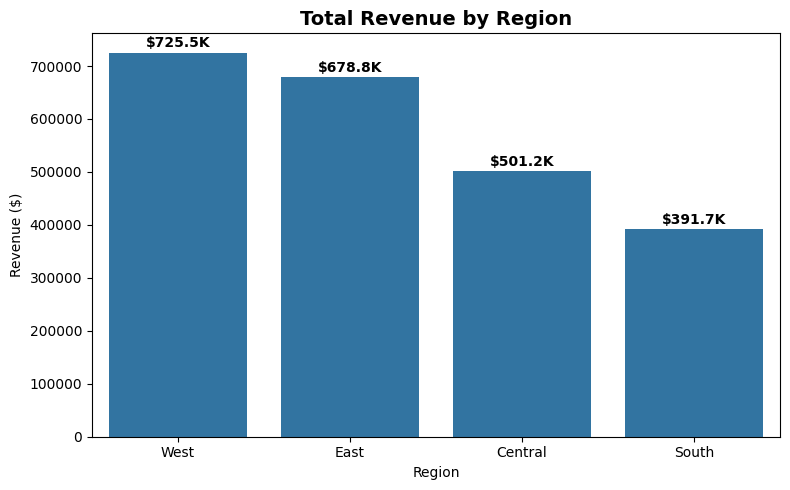

In [26]:
# Visualize revenue by region

region_sales = (
    df.groupby("Region")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=region_sales.index,
    y=region_sales.values
)

plt.title("Total Revenue by Region", fontsize=14, fontweight="bold")
plt.xlabel("Region")
plt.ylabel("Revenue ($)")

# Add value labels
for i, value in enumerate(region_sales.values):
    plt.text(i, value + 10000, f"${value/1000:.1f}K",
             ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

In [27]:
# Top 10 products by revenue

top_products = (
    df.groupby("Product Name")
      .agg(
          Revenue=("Sales", "sum"),
          Profit=("Profit", "sum"),
          Quantity=("Quantity", "sum")
      )
      .sort_values("Revenue", ascending=False)
      .head(10)
)

display(top_products.round(2))

,Revenue,Profit,Quantity
Product Name,,,
Canon imageCLASS 2200 Advanced Copier,61599.82,25199.93,20
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,27453.38,7753.04,31
Cisco TelePresence System EX90 Videoconferencing Unit,22638.48,-1811.08,6
HON 5400 Series Task Chairs for Big and Tall,21870.58,0.00,39
GBC DocuBind TL300 Electric Binding System,19823.48,2233.51,37
GBC Ibimaster 500 Manual ProClick Binding System,19024.50,760.98,48
Hewlett Packard LaserJet 3310 Copier,18839.69,6983.88,38
"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",18374.90,4094.98,12
GBC DocuBind P400 Electric Binding System,17965.07,-1878.17,27


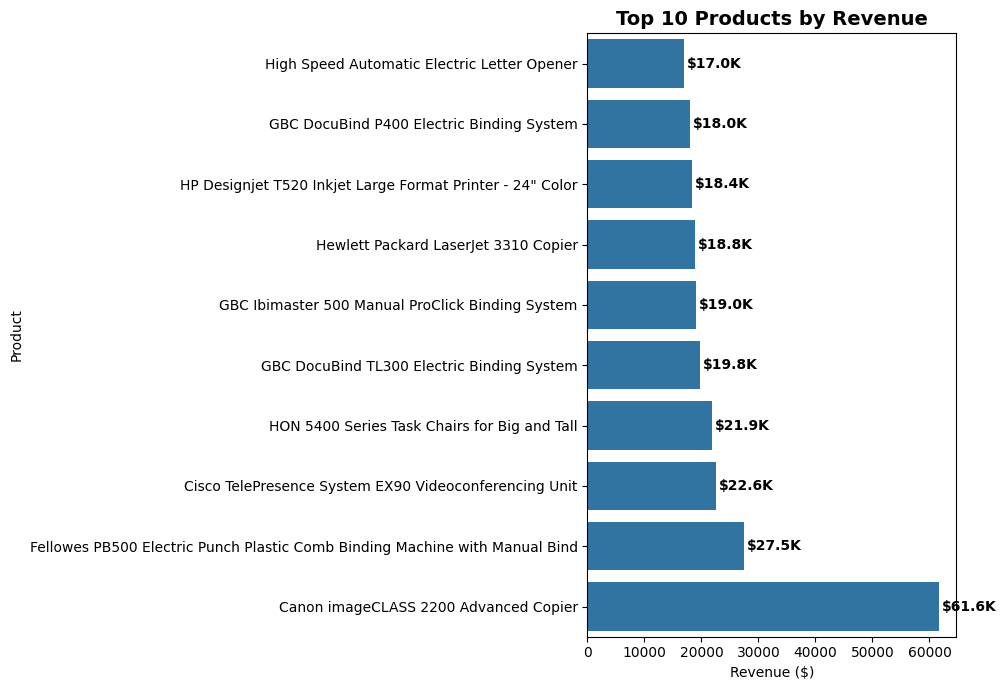

In [28]:
# Visualize top 10 products by revenue

top_10_sales = (
    df.groupby("Product Name")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .sort_values()
)

plt.figure(figsize=(10, 7))

ax = sns.barplot(
    x=top_10_sales.values,
    y=top_10_sales.index
)

plt.title("Top 10 Products by Revenue", fontsize=14, fontweight="bold")
plt.xlabel("Revenue ($)")
plt.ylabel("Product")

# Add revenue labels
for i, value in enumerate(top_10_sales.values):
    plt.text(value + 500, i, f"${value/1000:.1f}K",
             va="center", fontweight="bold")

plt.tight_layout()
plt.show()


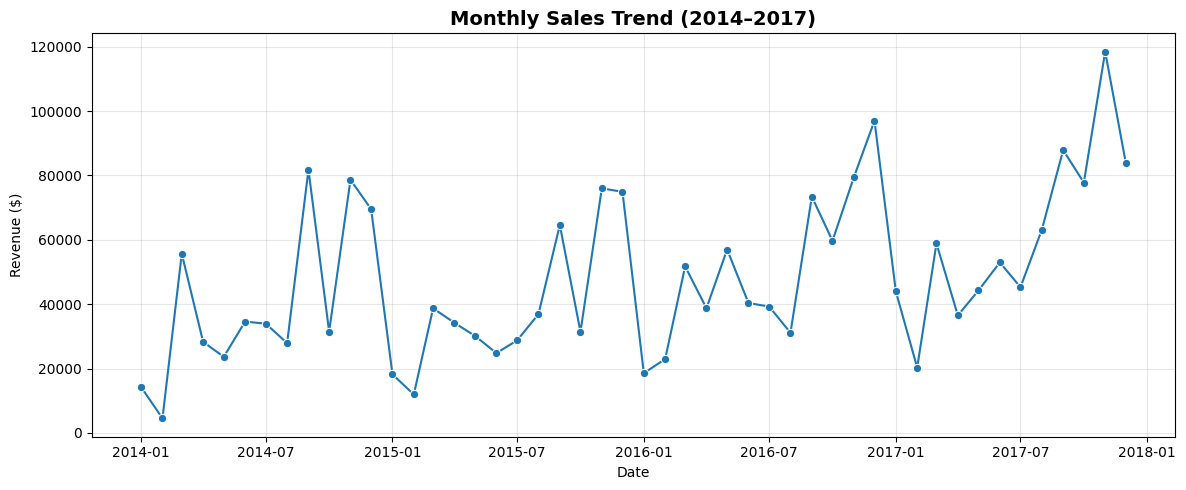

In [29]:
# Monthly sales trend

monthly_sales = (
    df.groupby(df["Order Date"].dt.to_period("M"))["Sales"]
      .sum()
      .reset_index()
)

# Convert period back to datetime for plotting
monthly_sales["Order Date"] = monthly_sales["Order Date"].dt.to_timestamp()

plt.figure(figsize=(12, 5))

sns.lineplot(
    data=monthly_sales,
    x="Order Date",
    y="Sales",
    marker="o"
)

plt.title("Monthly Sales Trend (2014–2017)", fontsize=14, fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Revenue ($)")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [30]:
# Analyze monthly seasonality across all years

monthly_seasonality = (
    df.groupby("Month")
      .agg(
          Average_Revenue=("Sales", "mean"),
          Total_Revenue=("Sales", "sum")
      )
)

# Calculate average monthly total revenue across the 4 years
monthly_totals = (
    df.groupby(["Year", "Month"])["Sales"]
      .sum()
      .reset_index()
)

average_monthly_sales = (
    monthly_totals.groupby("Month")["Sales"]
                  .mean()
                  .reindex(range(1, 13))
)

month_names = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

average_monthly_sales.index = month_names

display(average_monthly_sales.round(2))


,Sales
Jan,23731.21
Feb,14937.81
Mar,51251.37
Apr,34440.53
May,38757.20
Jun,38179.67
Jul,36809.52
Aug,39761.02
Sep,76912.49
Oct,50080.75


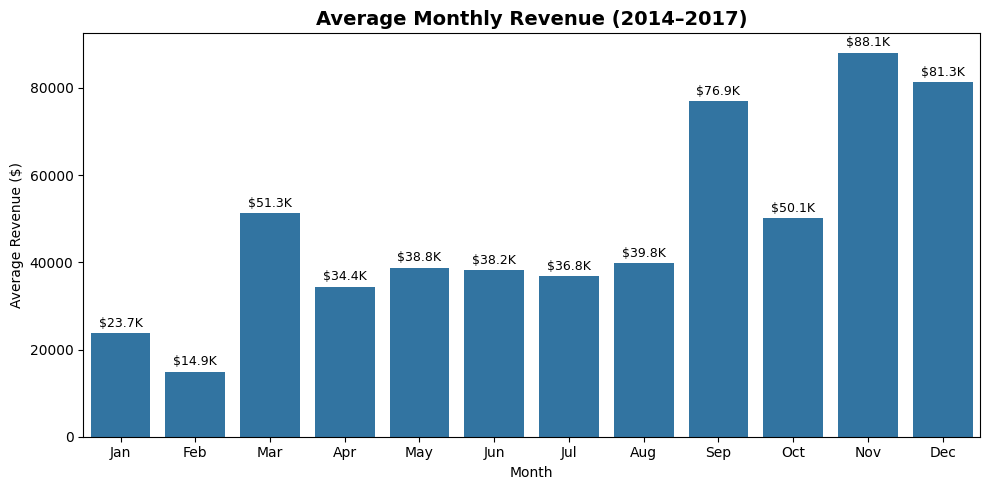

In [31]:
# Visualize average monthly sales seasonality

plt.figure(figsize=(10, 5))

ax = sns.barplot(
    x=average_monthly_sales.index,
    y=average_monthly_sales.values
)

plt.title("Average Monthly Revenue (2014–2017)",
          fontsize=14, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Average Revenue ($)")

# Add value labels
for i, value in enumerate(average_monthly_sales.values):
    plt.text(i, value + 1500, f"${value/1000:.1f}K",
             ha="center", fontsize=9)

plt.tight_layout()
plt.show()

In [32]:
# Analyze performance by product category

category_performance = (
    df.groupby("Category")
      .agg(
          Revenue=("Sales", "sum"),
          Profit=("Profit", "sum"),
          Quantity=("Quantity", "sum"),
          Orders=("Order ID", "nunique")
      )
      .sort_values("Revenue", ascending=False)
)

category_performance["Profit Margin (%)"] = (
    category_performance["Profit"] /
    category_performance["Revenue"] * 100
)

display(category_performance.round(2))

,Revenue,Profit,Quantity,Orders,Profit Margin (%)
Category,,,,,
Technology,836154.03,145454.95,6939,1544,17.40
Furniture,741999.80,18451.27,8028,1764,2.49
Office Supplies,719047.03,122490.80,22906,3742,17.04


In [33]:
# Analyze performance by sub-category

subcategory_performance = (
    df.groupby("Sub-Category")
      .agg(
          Revenue=("Sales", "sum"),
          Profit=("Profit", "sum"),
          Quantity=("Quantity", "sum")
      )
      .sort_values("Revenue", ascending=False)
)

subcategory_performance["Profit Margin (%)"] = (
    subcategory_performance["Profit"] /
    subcategory_performance["Revenue"] * 100
)

display(subcategory_performance.round(2))

,Revenue,Profit,Quantity,Profit Margin (%)
Sub-Category,,,,
Phones,330007.05,44515.73,3289,13.49
Chairs,328449.10,26590.17,2356,8.10
Storage,223843.61,21278.83,3158,9.51
Tables,206965.53,-17725.48,1241,-8.56
Binders,203412.73,30221.76,5974,14.86
Machines,189238.63,3384.76,440,1.79
Accessories,167380.32,41936.64,2976,25.05
Copiers,149528.03,55617.82,234,37.20
Bookcases,114880.00,-3472.56,868,-3.02


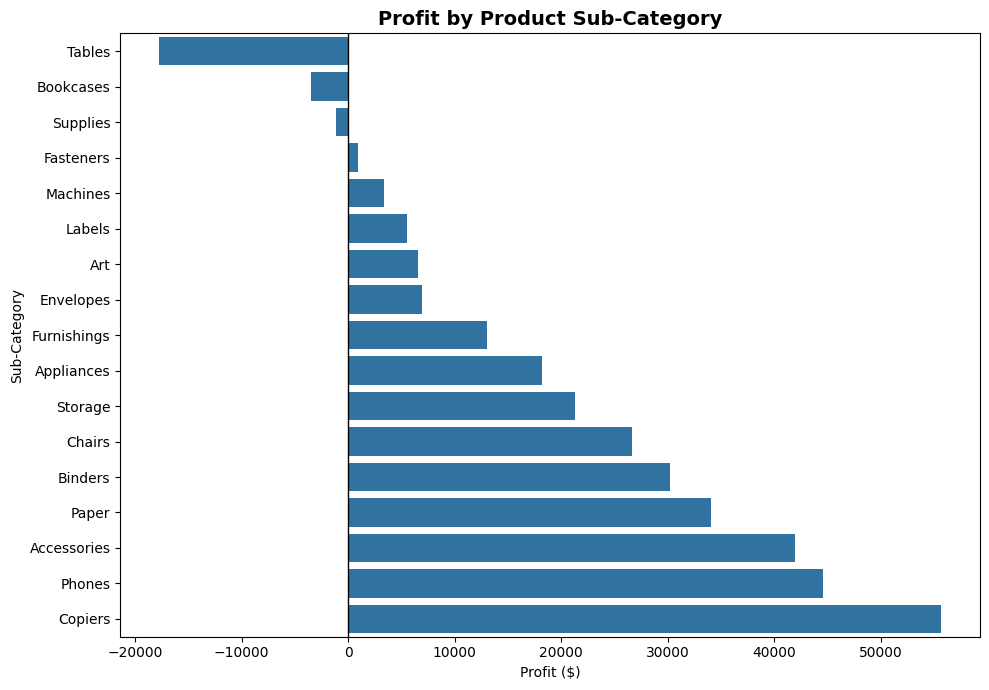

In [34]:
# Visualize profit by sub-category

subcategory_profit = (
    df.groupby("Sub-Category")["Profit"]
      .sum()
      .sort_values()
)

plt.figure(figsize=(10, 7))

ax = sns.barplot(
    x=subcategory_profit.values,
    y=subcategory_profit.index
)

plt.axvline(0, color="black", linewidth=1)

plt.title("Profit by Product Sub-Category",
          fontsize=14, fontweight="bold")
plt.xlabel("Profit ($)")
plt.ylabel("Sub-Category")

plt.tight_layout()
plt.show()

In [35]:
# Analyze profitability by discount level

discount_analysis = (
    df.groupby("Discount")
      .agg(
          Revenue=("Sales", "sum"),
          Profit=("Profit", "sum"),
          Orders=("Order ID", "nunique")
      )
      .reset_index()
)

discount_analysis["Profit Margin (%)"] = (
    discount_analysis["Profit"] /
    discount_analysis["Revenue"] * 100
)

display(discount_analysis.round(2))

,Discount,Revenue,Profit,Orders,Profit Margin (%)
0,0.00,1087908.47,320987.60,2644,29.51
1,0.10,54369.35,9029.18,89,16.61
2,0.15,27558.52,1418.99,51,5.15
3,0.20,764594.37,90337.31,2407,11.82
4,0.30,103226.66,-10369.28,211,-10.05
5,0.32,14493.46,-2391.14,27,-16.50
6,0.40,116417.78,-23057.05,185,-19.81
7,0.45,5484.97,-2493.11,10,-45.45
8,0.50,58918.54,-20506.43,64,-34.80
9,0.60,6644.70,-5944.66,127,-89.46


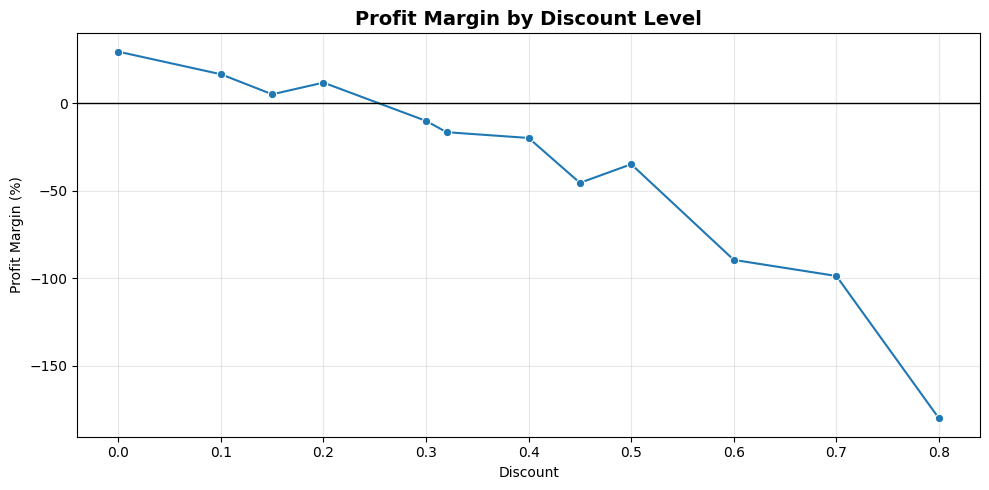

In [36]:
# Visualize relationship between discount and profit margin

plt.figure(figsize=(10, 5))

sns.lineplot(
    data=discount_analysis,
    x="Discount",
    y="Profit Margin (%)",
    marker="o"
)

plt.axhline(0, color="black", linewidth=1)

plt.title("Profit Margin by Discount Level",
          fontsize=14, fontweight="bold")
plt.xlabel("Discount")
plt.ylabel("Profit Margin (%)")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [37]:
# Analyze yearly sales and profit performance

yearly_performance = (
    df.groupby("Year")
      .agg(
          Revenue=("Sales", "sum"),
          Profit=("Profit", "sum"),
          Orders=("Order ID", "nunique")
      )
)

yearly_performance["Revenue Growth (%)"] = (
    yearly_performance["Revenue"].pct_change() * 100
)

yearly_performance["Profit Growth (%)"] = (
    yearly_performance["Profit"].pct_change() * 100
)

display(yearly_performance.round(2))

,Revenue,Profit,Orders,Revenue Growth (%),Profit Growth (%)
Year,,,,,
2014,484247.50,49543.97,969,NaN,NaN
2015,470532.51,61618.60,1038,-2.83,24.37
2016,609205.60,81795.17,1315,29.47,32.74
2017,733215.26,93439.27,1687,20.36,14.24


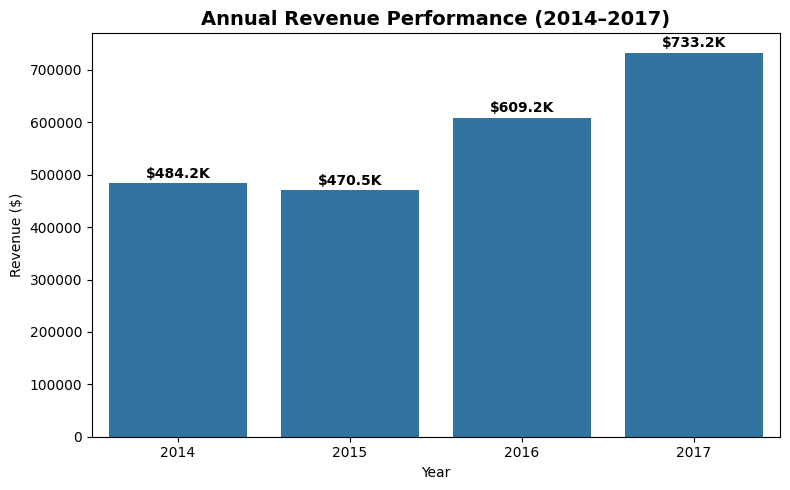

In [38]:
# Visualize yearly revenue performance

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=yearly_performance.index,
    y=yearly_performance["Revenue"]
)

plt.title("Annual Revenue Performance (2014–2017)",
          fontsize=14, fontweight="bold")
plt.xlabel("Year")
plt.ylabel("Revenue ($)")

for i, value in enumerate(yearly_performance["Revenue"]):
    plt.text(i, value + 10000, f"${value/1000:.1f}K",
             ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

## 🔍 Key Business Insights

1. **Overall Performance:** The dataset generated approximately **$2.30 million in revenue** and **$286.4K in profit** from **5,009 unique orders**, with an Average Order Value of **$458.61**.

2. **Regional Performance:** The **West region** was the strongest performer, generating approximately **$725.5K in revenue** and **$108.4K in profit**, with a profit margin of **14.94%**.

3. **Product Performance:** The **Canon imageCLASS 2200 Advanced Copier** was the highest-revenue product, generating approximately **$61.6K in sales** and **$25.2K in profit**.

4. **Seasonality:** Sales showed clear seasonal variation. **November, December, and September** recorded the highest average monthly revenues, while **February** recorded the lowest.

5. **Category Performance:** **Technology** generated the highest category revenue (**$836.2K**) and profit (**$145.5K**). Furniture generated substantial revenue but had a much lower profit margin of only **2.49%**.

6. **Profitability Issues:** Within Furniture, **Tables** generated approximately **$207.0K in revenue** but recorded a **$17.7K loss**, making it the largest loss-making sub-category.

7. **Discount Pattern:** Higher discount levels were associated with substantially weaker profitability. In this dataset, discount levels of **30% and above** recorded negative aggregate profit margins.

8. **Annual Growth:** Revenue increased strongly after 2015, reaching approximately **$733.2K in 2017**. Profit increased each year and reached approximately **$93.4K in 2017**.

## 💡 Business Recommendations

1. **Prioritize High-Performing Regions:** Continue strengthening sales and customer-retention strategies in the **West and East regions**, which contribute the highest revenue.

2. **Focus on Profitable Product Categories:** Maintain strong availability and promotion of **Technology** and **Office Supplies**, as both categories generate healthy profit margins.

3. **Review Furniture Profitability:** Investigate pricing, costs, and discount strategies within the **Furniture** category, particularly **Tables and Bookcases**, which generated aggregate losses.

4. **Optimize Discount Strategy:** Review high-discount transactions carefully. In this dataset, discount levels of **30% and above were associated with negative aggregate profit margins**. Promotions should therefore be evaluated using both revenue and profitability.

5. **Prepare for Seasonal Demand:** Increase inventory and marketing readiness ahead of **September, November, and December**, which showed the strongest average monthly sales performance.

6. **Promote High-Value Products:** Products and sub-categories such as **Copiers, Phones, and Accessories** should receive attention because of their strong profit contribution.

7. **Monitor Growth:** With revenue and profit increasing strongly in **2016–2017**, management should continue tracking annual revenue growth, profit growth, and profit margin to ensure that sales expansion remains profitable.

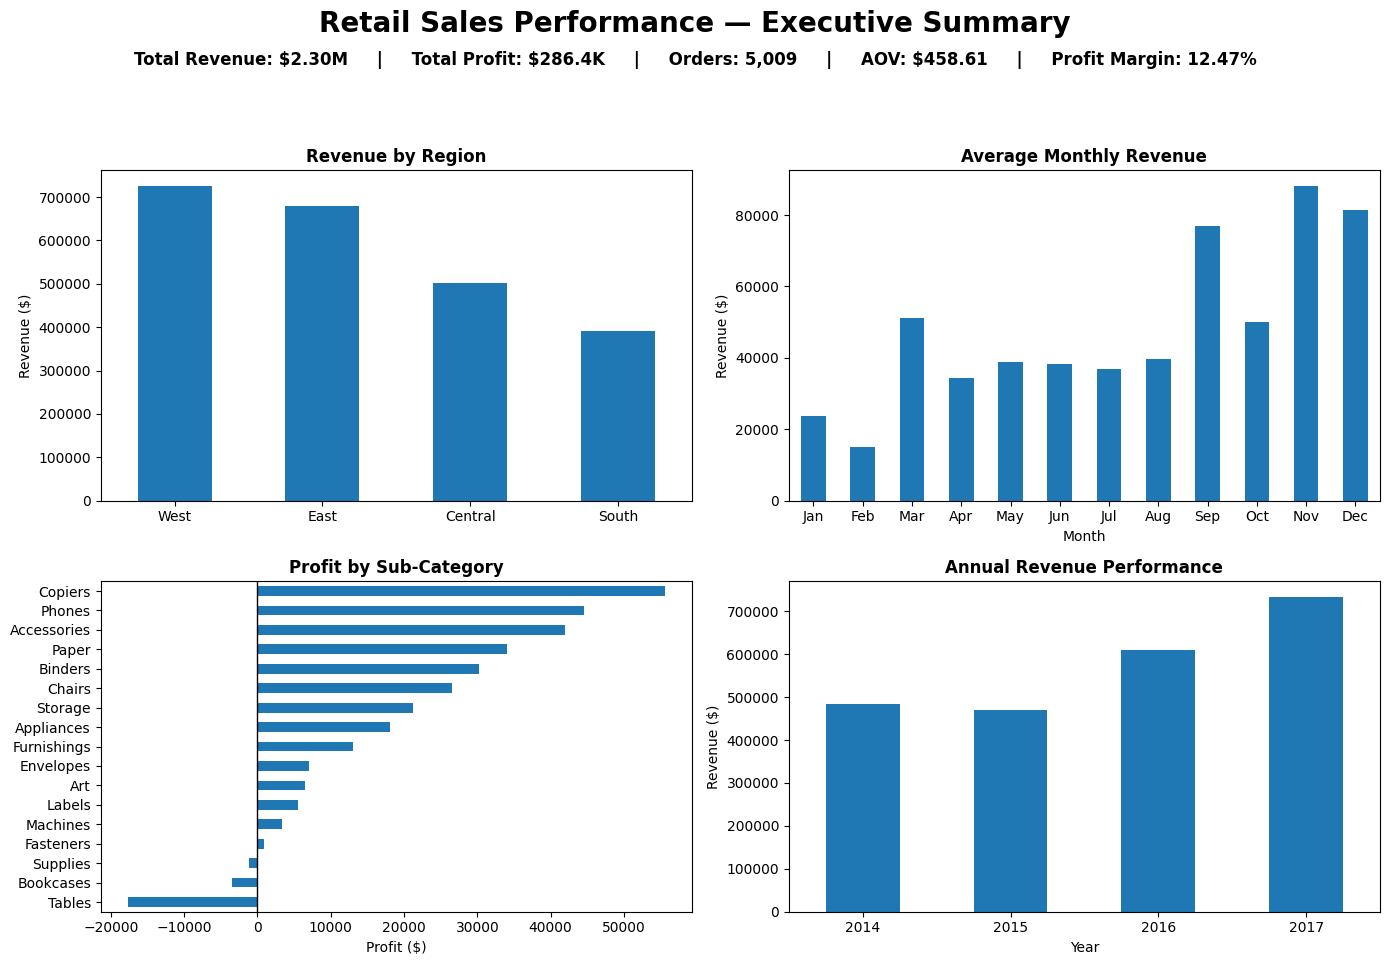

In [39]:
# Create one-page visual summary

fig = plt.figure(figsize=(14, 10))
fig.suptitle(
    "Retail Sales Performance — Executive Summary",
    fontsize=20,
    fontweight="bold",
    y=0.98
)

# KPI summary
profit_margin = (total_profit / total_revenue) * 100

kpi_text = (
    f"Total Revenue: ${total_revenue/1_000_000:.2f}M     |     "
    f"Total Profit: ${total_profit/1000:.1f}K     |     "
    f"Orders: {total_orders:,}     |     "
    f"AOV: ${average_order_value:.2f}     |     "
    f"Profit Margin: {profit_margin:.2f}%"
)

fig.text(
    0.5, 0.925, kpi_text,
    ha="center",
    fontsize=12,
    fontweight="bold"
)

# Chart 1: Revenue by Region
ax1 = fig.add_subplot(2, 2, 1)
region_sales.plot(kind="bar", ax=ax1)
ax1.set_title("Revenue by Region", fontweight="bold")
ax1.set_xlabel("")
ax1.set_ylabel("Revenue ($)")
ax1.tick_params(axis="x", rotation=0)

# Chart 2: Average Monthly Revenue
ax2 = fig.add_subplot(2, 2, 2)
average_monthly_sales.plot(kind="bar", ax=ax2)
ax2.set_title("Average Monthly Revenue", fontweight="bold")
ax2.set_xlabel("Month")
ax2.set_ylabel("Revenue ($)")
ax2.tick_params(axis="x", rotation=0)

# Chart 3: Sub-Category Profit
ax3 = fig.add_subplot(2, 2, 3)
subcategory_profit.plot(kind="barh", ax=ax3)
ax3.axvline(0, color="black", linewidth=1)
ax3.set_title("Profit by Sub-Category", fontweight="bold")
ax3.set_xlabel("Profit ($)")
ax3.set_ylabel("")

# Chart 4: Annual Revenue
ax4 = fig.add_subplot(2, 2, 4)
yearly_performance["Revenue"].plot(kind="bar", ax=ax4)
ax4.set_title("Annual Revenue Performance", fontweight="bold")
ax4.set_xlabel("Year")
ax4.set_ylabel("Revenue ($)")
ax4.tick_params(axis="x", rotation=0)

plt.tight_layout(rect=[0, 0.02, 1, 0.90])

# Save summary
plt.savefig(
    "Retail_Sales_One_Page_Summary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 📌 Conclusion

This project analyzed retail sales performance from **2014 to 2017** using revenue, profitability, regional performance, product performance, seasonality, and discount patterns.

The analysis found that the **West region** generated the highest revenue, while **Technology** was the strongest category in terms of both revenue and profit. Sales displayed clear seasonal variation, with stronger average performance during **September, November, and December**.

Profitability analysis also identified important areas for improvement. **Tables and Bookcases** generated aggregate losses, while higher discount levels were associated with substantially lower profit margins. In contrast, sub-categories such as **Copiers, Phones, and Accessories** made strong profit contributions.

Overall, the findings demonstrate how retail transaction data can be transformed into actionable business insights for **sales planning, profitability management, inventory preparation, and discount strategy**.